# Geographical overview

In [1]:
import os
import pickle as pkl

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from newutils.math import compute_corr_matrix
from oldutils.datasets import ROOT_FOLDER, HydroStaticFeaturesFiles
from config.Constants import ARTIFACTS

os.chdir(ROOT_FOLDER)

In [2]:
OUTDIR = ARTIFACTS / "plots"
OUTDIR.mkdir(parents=True, exist_ok=True)

In [3]:
hsff = HydroStaticFeaturesFiles().dataframe

In [4]:
# hsff.select(["lat", "log"]).collect()

import geopandas

gdf = geopandas.read_file("data/GTS_river_gauges.gpkg")
gdf

,gauge_id,name_ru,name_en,geometry
0,1500048,ВДХР ИВАНЬКОВСКОЕ - ОГП ДУБНА,VDHR IVAN'KOVSKOE - OGP DUBNA,POINT (37.13125 56.71625)
1,1500056,ВДХР УГЛИЧСКОЕ - Г. КИМРЫ,VDHR UGLIChSKOE - G. KIMRY,POINT (37.36458 56.87375)
2,1500072,ВДХР УГЛИЧСКОЕ - Г. УГЛИЧ,VDHR UGLIChSKOE - G. UGLICh,POINT (38.29958 57.52625)
3,1500099,ВДХР РЫБИНСКОЕ - ПГТ МЫШКИНО,VDHR RYBINSKOE - PGT MYShKINO,POINT (38.45292 57.77542)
4,1500119,ВДХР РЫБИНСКОЕ - С. БРЕЙТОВО,VDHR RYBINSKOE - S. BREJTOVO,POINT (37.88458 58.31292)
...,...,...,...,...
2198,4240,р.Бирюкан - пос.Восточный,r.Birjukan - pos.Vostochnyj,POINT (143.03127 53.49538)
2199,1105,руч.Встреча - выше устья руч.Угроза,ruch.Vstrecha - vyshe ust'ja ruch.Ugroza,POINT (147.66247 61.85056)
2200,4005,р.Охинка - г.Оха,r.Ohinka - g.Oha,POINT (142.93783 53.57969)
2201,76491,р.Чекмагуш - с.Чекмагуш,r.Chekmagush - s.Chekmagush,POINT (54.67846 55.13715)


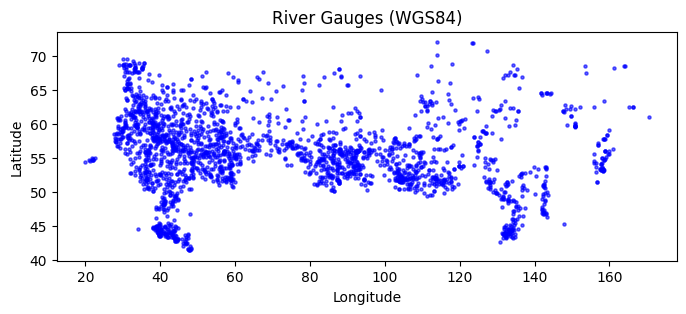

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(
    ax=ax,
    marker="o",
    color="blue",
    markersize=5,
    alpha=0.6,
)
ax.set_title("River Gauges (WGS84)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [6]:
coords = gdf.geometry.apply(lambda p: (p.y, p.x))
gdf["latitude"]  = coords.apply(lambda t: t[0])
gdf["longitude"] = coords.apply(lambda t: t[1])

In [11]:
gdf["latitude"].min().item(), gdf["latitude"].max().item(), gdf["longitude"].min().item(), gdf["longitude"].max().item()

(41.42762887063931, 71.9648826311035, 19.922287798704144, 170.50037423049775)

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


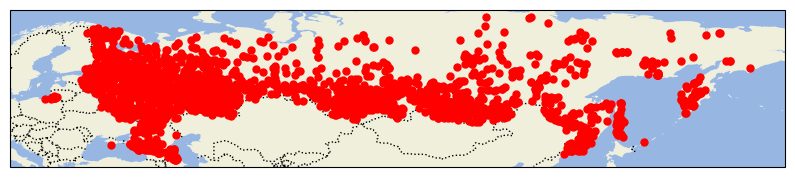

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')

locations = [(lat, log) for (lat, log) in zip(gdf["latitude"], gdf["longitude"])]
for lat, lon in locations:
    ax.plot(lon, lat, marker='o', color='red', markersize=5)

plt.show()


In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

# Load elevation data (example using ETOPO1)
url = "https://www.ngdc.noaa.gov/thredds/dodsC/global_topo_etopo1"
ds = xr.open_dataset(url)

# Extract elevation data
elevation = ds["z"]

# Create a figure
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_title("Global Height Map")

# Plot elevation data
ax.contourf(ds["lon"], ds["lat"], elevation, cmap="terrain")

# Add features
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.show()


OSError: [Errno -90] NetCDF: file not found: 'https://www.ngdc.noaa.gov/thredds/dodsC/global_topo_etopo1'

/home/khuzin/.cache/pypoetry/virtualenvs/pro-1-experiments-jmzHMVzz-py3.11/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


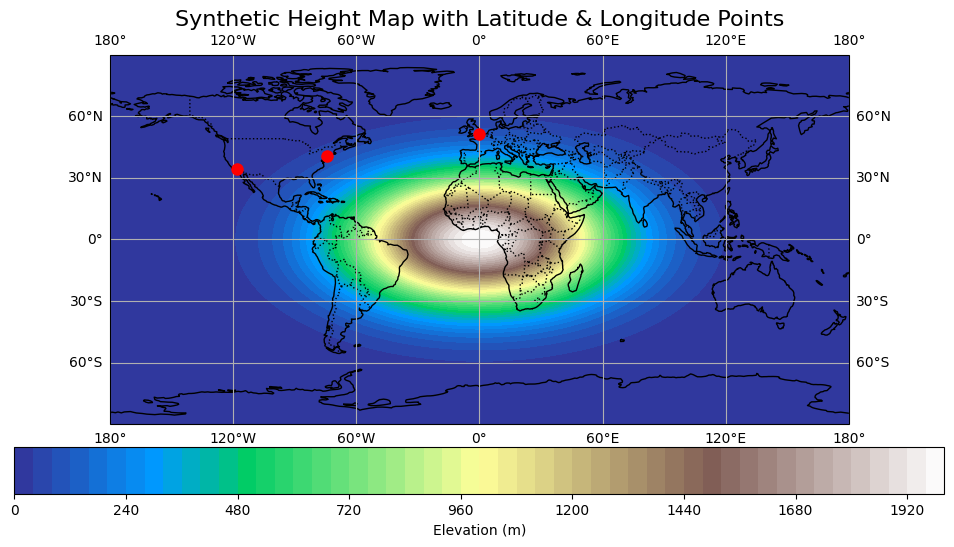

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- Create a Synthetic Elevation Data ---

# Define the longitude and latitude arrays.
# Here we use 1-degree spacing for a quick example.
lons = np.linspace(-180, 180, 361)
lats = np.linspace(-90, 90, 181)

# Create a 2D grid of lon/lat values.
lon2d, lat2d = np.meshgrid(lons, lats)

# Create synthetic "elevation" data.
# This example simulates a Gaussian hill centered at lon=0, lat=0.
elevation = 2000 * np.exp(-((lon2d / 60) ** 2 + (lat2d / 30) ** 2))

# --- Define an Array of (lat, lon) Points --- 
# Note: Each row is in the format [latitude, longitude].
points = np.array([
    [40.7128, -74.0060],   # New York City
    [34.0522, -118.2437],  # Los Angeles
    [51.5074, -0.1278]     # London
])

# --- Plotting the Map with Cartopy ---

# Create a figure with a PlateCarree projection (geographical projection).
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_global()  # Set the extent to the whole world
ax.set_title("Synthetic Height Map with Latitude & Longitude Points", fontsize=16)

# Plot the synthetic elevation data using contour filling.
# The "transform" parameter tells Cartopy which coordinate system the data is in.
cf = ax.contourf(lon2d, lat2d, elevation, levels=60, cmap='terrain', transform=ccrs.PlateCarree())

# Add a colorbar to show elevation values.
plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, label='Elevation (m)')

# Add common map features.
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Overlay the array of points.
# IMPORTANT: When plotting, remember that Cartopy expects the x-coordinate to be longitude and y-coordinate to be latitude.
for point in points:
    lat, lon = point  # Our points are in (lat, lon) format defined above.
    ax.plot(lon, lat, marker='o', color='red', markersize=8, transform=ccrs.PlateCarree())

plt.show()


In [13]:
# import folium

# # 1) Compute center
# center_lat = gdf["latitude"].mean()
# center_lon = gdf["longitude"].mean()

# # 2) Initialize map
# m = folium.Map(location=[center_lat, center_lon], 
#                zoom_start=5,            # adjust as needed
#                tiles="CartoDB positron")

# # 3) Add each gauge as a marker
# for _, row in gdf.iterrows():
#     folium.CircleMarker(
#         location=[row["latitude"], row["longitude"]],
#         radius=4,                     # marker size in pixels
#         color="blue",
#         fill=True,
#         fill_opacity=0.6,
#         popup=row["name_en"]          # click to see the English name
#     ).add_to(m)

# # 4) Display map in Jupyter, or save to HTML:
# m.save("river_gauges_map.html")
# m  # if in a Jupyter notebook, this will render the map inline
